# RF-DETR / detección de placas en Docker

Adaptado de la guía [Object detection](https://huggingface.co/docs/transformers/tasks/object_detection) de Transformers,
que ajusta [RF-DETR](https://huggingface.co/Roboflow/rf-detr-medium) (el detector abierto de Roboflow). Aquí se entrena
con el dataset [justjuu/license-plate-detection](https://huggingface.co/datasets/justjuu/license-plate-detection) para
detectar la región de la placa en imágenes de vehículos; los recortes servirán después como entrada del OCR.

Selecciona el kernel **Python (RF-DETR)**: usa Transformers 5 en un entorno separado del de TrOCR. Las dependencias
se instalan al construir la imagen (ver `env-detr.yml`).

Cambios respecto a la guía:

* El dataset ya trae las particiones `train`, `validation` y `test`: se usan tal cual en lugar de `train_test_split`,
  y `test` se reserva para la evaluación final.
* Las categorías son `ClassLabel` (enteros) y no hay columnas `width`/`height`: se leen del propio dataset y de la imagen.
* `prepare_example` lee el tamaño sin decodificar la imagen (`decode=False`) para que `map` no vuelva a comprimir los JPEG,
  y recorre `objects["bbox"]` (en la guía, `bboxes` se vacía antes del bucle y se descartarían todas las cajas).
* `load_best_model_at_end` no recarga bien los pesos de RF-DETR: el mejor checkpoint se recarga con `from_pretrained`.
* Los resultados se guardan en `outputs/rf_detr_license_plates`. `push_to_hub` está desactivado por defecto.
* `bf16` solo se activa si la GPU lo soporta.

Si quieres subir el modelo al Hub, pon `PUSH_TO_HUB = True` e inicia sesión con tu token. Definimos las constantes
globales: el modelo, el dataset y las rutas del proyecto. Esta guía usa RF-DETR, pero puedes elegir cualquier modelo de
detección de Transformers.

In [1]:
import os
from pathlib import Path

import torch

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent
OUTPUT_DIR = Path(os.environ.get("DETR_OUTPUT_DIR", project_dir / "outputs" / "rf_detr_license_plates"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "Roboflow/rf-detr-medium"
DATASET_NAME = "justjuu/license-plate-detection"
DATASET_REVISION = "b76dbba86154c33fa370bc3087fbc7c766845a66"
PUSH_TO_HUB = False

print("Salida:", OUTPUT_DIR)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No disponible")

Salida: /home/mambauser/workspace/outputs/rf_detr_license_plates
GPU: NVIDIA GeForce RTX 5060 Ti


In [2]:
if PUSH_TO_HUB:
    from huggingface_hub import notebook_login

    notebook_login()

## Cargar el dataset de placas

[justjuu/license-plate-detection](https://huggingface.co/datasets/justjuu/license-plate-detection) es una versión en
formato Hugging Face de un export COCO de Roboflow. Tiene una sola clase, `license_plate`, y las cajas vienen en formato
COCO `(x, y, w, h)`.

Cargamos el dataset y extraemos las categorías. El dataset ya tiene particiones.

In [3]:
from datasets import load_dataset

ds = load_dataset(DATASET_NAME, revision=DATASET_REVISION)
print(ds)

CATEGORIES = ds["train"].features["objects"]["category"].feature.names
label2id = {label: i for i, label in enumerate(CATEGORIES)}
id2label = {i: label for label, i in label2id.items()}
print(f"Categories ({len(CATEGORIES)}): {CATEGORIES}")

README.md:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  168MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 46.2MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6176 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1765 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/882 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'objects'],
        num_rows: 6176
    })
    validation: Dataset({
        features: ['image', 'objects'],
        num_rows: 1765
    })
    test: Dataset({
        features: ['image', 'objects'],
        num_rows: 882
    })
})
Categories (1): ['license_plate']


Las categorías ya son ids enteros. Calculamos las áreas, recortamos las cajas al tamaño de la imagen y descartamos las
degeneradas antes de entrenar. El dataset no incluye `width`/`height`, así que se toman de la imagen:

In [4]:
import io

from datasets import Image
from PIL import Image as PILImage


def prepare_example(example, idx):
    objects = example["objects"]
    # Solo se lee la cabecera de la imagen para obtener su tamaño.
    img_w, img_h = PILImage.open(io.BytesIO(example["image"]["bytes"])).size
    # Se recorre objects["bbox"]: en la guía, `bboxes` se reasigna a [] antes del bucle.
    bboxes, cats, areas, ids = [], [], [], []
    for i, (bbox, cat) in enumerate(zip(objects["bbox"], objects["category"])):
        x, y, w, h = bbox
        if w <= 0 or h <= 0:
            continue
        x = max(0.0, min(x, img_w))
        y = max(0.0, min(y, img_h))
        w = min(w, img_w - x)
        h = min(h, img_h - y)
        if w <= 0 or h <= 0:
            continue
        bboxes.append([x, y, w, h])
        cats.append(cat)
        areas.append(w * h)
        ids.append(i)
    return {
        "image_id": idx,
        "width": img_w, "height": img_h,
        "objects": {"id": ids, "bbox": bboxes, "category": cats, "area": areas},
    }

# Con decode=False, map conserva los bytes originales de los JPEG en lugar de recomprimirlos.
ds_prepared = ds.cast_column("image", Image(decode=False)).map(prepare_example, with_indices=True)
ds_prepared = ds_prepared.cast_column("image", Image())
ds_prepared = ds_prepared.filter(lambda x: len(x["objects"]["bbox"]) > 0)

train_ds = ds_prepared["train"]
val_ds = ds_prepared["validation"]
test_ds = ds_prepared["test"]
print(f"Train: {len(train_ds)}, Validation: {len(val_ds)}, Test: {len(test_ds)}")

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/1765 [00:00<?, ? examples/s]

Map:   0%|          | 0/882 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6176 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1765 [00:00<?, ? examples/s]

Filter:   0%|          | 0/882 [00:00<?, ? examples/s]

Train: 6176, Validation: 1765, Test: 882


## Preprocesar los datos

[`AutoImageProcessor`] se encarga de procesar las imágenes para crear `pixel_values`, `pixel_mask` y `labels` con los
que el modelo puede entrenar. Redimensiona, rellena y normaliza. Además, se pueden añadir aumentos de datos aleatorios
(ver más abajo) para mejorar la generalización.

In [5]:
import numpy as np
from functools import partial
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

preprocessor_config.json:   0%|          | 0.00/442 [00:00<?, ?B/s]

El `image_processor` espera las anotaciones en formato COCO: `{'image_id': int, 'annotations': list[Dict]}`. Damos
formato a las anotaciones de cada ejemplo y dejamos que el procesador haga el resto:

In [6]:
def format_image_annotations_as_coco(image_id, categories, areas, bboxes):
    annotations = []
    for category, area, bbox in zip(categories, areas, bboxes):
        annotations.append({
            "image_id": image_id,
            "category_id": category,
            "iscrowd": 0,
            "area": area,
            "bbox": list(bbox),
        })
    return {"image_id": image_id, "annotations": annotations}

def transform_batch(examples, image_processor):
    images = []
    annotations = []
    for image_id, image, objects in zip(examples["image_id"], examples["image"], examples["objects"]):
        images.append(np.array(image.convert("RGB")))
        formatted = format_image_annotations_as_coco(
            image_id, objects["category"], objects["area"], objects["bbox"]
        )
        annotations.append(formatted)
    result = image_processor(images=images, annotations=annotations, return_tensors="pt")
    result.pop("pixel_mask", None)
    return result

transform_fn = partial(transform_batch, image_processor=image_processor)
train_ds = train_ds.with_transform(transform_fn)
val_ds = val_ds.with_transform(transform_fn)
test_ds = test_ds.with_transform(transform_fn)

### Aumento de datos

La transformación anterior solo redimensiona y normaliza. Los aumentos aleatorios sobre la partición de
**entrenamiento** suelen mejorar la generalización; validación y prueba se quedan sin aumentos para que la evaluación
sea determinista. [Albumentations](https://albumentations.ai/) transforma la imagen y sus cajas a la vez. Definimos un
pipeline con `bbox_params` y recalculamos las áreas a partir de las cajas aumentadas:

In [7]:
import albumentations as A

train_augment = A.Compose(
    [
        A.Perspective(p=0.1),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.1),
    ],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"], clip=True, min_area=25),
)

def augment_and_transform_batch(examples, image_processor, transform):
    images = []
    annotations = []
    for image_id, image, objects in zip(examples["image_id"], examples["image"], examples["objects"]):
        image = np.array(image.convert("RGB"))
        output = transform(image=image, bboxes=objects["bbox"], category=objects["category"])
        images.append(output["image"])
        areas = [w * h for (_, _, w, h) in output["bboxes"]]
        formatted = format_image_annotations_as_coco(
            image_id, output["category"], areas, output["bboxes"]
        )
        annotations.append(formatted)
    result = image_processor(images=images, annotations=annotations, return_tensors="pt")
    result.pop("pixel_mask", None)
    return result

Aplicamos la transformación con aumentos solo a entrenamiento y mantenemos `transform_fn` para validación y prueba:

In [8]:
train_augment_fn = partial(augment_and_transform_batch, image_processor=image_processor, transform=train_augment)
train_ds = train_ds.with_transform(train_augment_fn)
val_ds = val_ds.with_transform(transform_fn)
test_ds = test_ds.with_transform(transform_fn)

Creamos un `collate_fn` para agrupar las imágenes en lotes:

In [9]:
import torch

def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    if "pixel_mask" in batch[0]:
        data["pixel_mask"] = torch.stack([x["pixel_mask"] for x in batch])
    return data

## Función para calcular mAP

Los detectores se evalúan con [métricas estilo COCO](https://cocodataset.org/#detection-eval). Usamos `torchmetrics`
para calcular `mAP` (mean average precision) y `mAR` (mean average recall) dentro de `compute_metrics` para el
[`Trainer`].

Durante el entrenamiento las cajas están en formato `YOLO` (normalizado), pero las métricas se calculan en formato
`Pascal VOC` (absoluto) para tratar bien las áreas. Definimos la conversión:

In [10]:
from transformers.image_transforms import center_to_corners_format

def convert_bbox_yolo_to_pascal(boxes, image_size):
    """
    Convert bounding boxes from YOLO format (x_center, y_center, width, height) in range [0, 1]
    to Pascal VOC format (x_min, y_min, x_max, y_max) in absolute coordinates.

    Args:
        boxes (torch.Tensor): Bounding boxes in YOLO format
        image_size (tuple[int, int]): Image size in format (height, width)

    Returns:
        torch.Tensor: Bounding boxes in Pascal VOC format (x_min, y_min, x_max, y_max)
    """
    # convert center to corners format
    boxes = center_to_corners_format(boxes)

    # convert to absolute coordinates
    height, width = image_size
    boxes = boxes * torch.tensor([[width, height, width, height]])

    return boxes

En `compute_metrics` recogemos las cajas, puntuaciones y etiquetas predichas y reales del bucle de evaluación y las
pasamos al cálculo de la métrica.

In [11]:
from dataclasses import dataclass
from torchmetrics.detection.mean_ap import MeanAveragePrecision


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


def _get_orig_size(image_target):
    """Robust orig_size extraction - Trainer serialization can truncate to 1 element."""
    orig = np.atleast_1d(np.asarray(image_target["orig_size"])).flatten()
    if len(orig) >= 2:
        return (int(orig[0]), int(orig[1]))
    return (int(orig[0]), int(orig[0]))

@torch.no_grad()
def compute_metrics(evaluation_results, image_processor, threshold=0.0, id2label=None):
    predictions, targets = evaluation_results.predictions, evaluation_results.label_ids
    image_sizes = []
    post_processed_targets = []
    post_processed_predictions = []

    for batch in targets:
        batch_sizes = []
        for image_target in batch:
            h, w = _get_orig_size(image_target)
            batch_sizes.append([h, w])
            boxes = torch.tensor(image_target["boxes"])
            boxes = convert_bbox_yolo_to_pascal(boxes, (h, w))
            labels = torch.tensor(image_target["class_labels"])
            post_processed_targets.append({"boxes": boxes, "labels": labels})
        image_sizes.append(torch.tensor(batch_sizes))

    for batch, target_sizes in zip(predictions, image_sizes):
        batch_logits, batch_boxes = batch[1], batch[2]
        output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
        post_processed_output = image_processor.post_process_object_detection(
            output, threshold=threshold, target_sizes=target_sizes
        )
        post_processed_predictions.extend(post_processed_output)

    metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
    metric.update(post_processed_predictions, post_processed_targets)
    metrics = metric.compute()

    # Con una sola clase torchmetrics devuelve tensores 0-d; atleast_1d permite recorrerlos.
    classes = torch.atleast_1d(metrics.pop("classes"))
    map_per_class = torch.atleast_1d(metrics.pop("map_per_class"))
    mar_100_per_class = torch.atleast_1d(metrics.pop("mar_100_per_class"))
    for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
        class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
        metrics[f"map_{class_name}"] = class_map
        metrics[f"mar_100_{class_name}"] = class_mar

    metrics = {k: round(v.item(), 4) for k, v in metrics.items()}
    return metrics

eval_compute_metrics_fn = partial(
    compute_metrics, image_processor=image_processor, id2label=id2label, threshold=0.0
)

## Entrenar el detector

Con los datos y la métrica listos, entrenamos:

1. Cargar el modelo con [`AutoModelForObjectDetection`] desde el mismo checkpoint que el preprocesado.
2. Definir los hiperparámetros en [`TrainingArguments`].
3. Pasar los argumentos al [`Trainer`] junto con el modelo, los datasets, el procesador y el collator.
4. Llamar a [`~Trainer.train`].

Pasamos `label2id` e `id2label` y `ignore_mismatched_sizes=True` para sustituir la cabeza de clasificación de COCO por
una nueva de una sola clase.

In [12]:
from transformers import AutoModelForObjectDetection

model = AutoModelForObjectDetection.from_pretrained(
    MODEL_NAME,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

config.json:   0%|          | 0.00/5.77k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  135MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

[transformers] RfDetrForObjectDetection LOAD REPORT from: Roboflow/rf-detr-medium
Key                                       | Status   |                                                                                        
------------------------------------------+----------+----------------------------------------------------------------------------------------
model.enc_out_class_embed.{0...12}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([91, 256]) vs model:torch.Size([1, 256])
model.enc_out_class_embed.{0...12}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([91]) vs model:torch.Size([1])          
class_embed.bias                          | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([91]) vs model:torch.Size([1])          
class_embed.weight                        | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([91, 256]) vs model:torch.Size([1, 256])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did n

Notas importantes (de la guía):

- No elimines las columnas sin usar: se perdería la columna `image` y no se podrían crear los `pixel_values`. Por eso
  `remove_unused_columns=False`.
- `eval_do_concat_batches=False` es necesario para evaluar bien: cada imagen tiene un número distinto de cajas.

`report_to="trackio"` registra las métricas en local (en la caché de Hugging Face), sin crear ningún Space. Si la GPU se
queda sin memoria, reduce `per_device_train_batch_size` a 4 o 2.

In [13]:
from transformers import TrainingArguments

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=5,
    bf16=use_bf16,
    per_device_train_batch_size=8,
    dataloader_num_workers=4,
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    weight_decay=1e-4,
    max_grad_norm=0.01,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    report_to="trackio",
    project="license-plate-detection",
    run_name="license-plate-detection",
    eval_do_concat_batches=False,
    push_to_hub=PUSH_TO_HUB,
    hub_private_repo=True,
)

Juntamos todo y llamamos a [`~transformers.Trainer.train`]:

In [14]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=image_processor,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
)

trainer.train()

* Trackio project initialized: license-plate-detection
* Trackio metrics logged to: /home/mambauser/.cache/huggingface/trackio
* psutil detected, enabling automatic CPU/system metrics logging
* Created new run: license-plate-detection


Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map License Plate,Mar 100 License Plate
1,9.302369,14.202677,0.640200,0.954800,0.753400,0.439200,0.684600,0.643800,0.669900,0.688000,0.723800,0.554700,0.763400,0.750600,0.640200,0.723800
2,5.321636,14.982073,0.662100,0.964200,0.785700,0.451500,0.705900,0.679600,0.687100,0.704300,0.721800,0.547700,0.762000,0.760900,0.662100,0.721800
3,4.971467,15.396103,0.654700,0.963000,0.786700,0.464300,0.695600,0.683700,0.684700,0.703500,0.724600,0.569200,0.760400,0.759800,0.654700,0.724600
4,4.542650,15.553896,0.677000,0.970200,0.801700,0.473800,0.719300,0.708500,0.699100,0.728900,0.748700,0.592400,0.784300,0.789700,0.677000,0.748700
5,4.402588,15.796196,0.688300,0.972000,0.824400,0.490900,0.728100,0.739400,0.707700,0.735900,0.757000,0.604900,0.791400,0.800000,0.688300,0.757000


/opt/conda/envs/detr/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/conda/envs/detr/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


...

/opt/conda/envs/detr/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.backbone.backbone.embeddings.cls_token', 'model.backbone.backbone.embeddings.mask_token', 'model.backbone.backbone.embeddings.position_embeddings', 'model.backbone.backbone.embeddings.patch_embeddings.projection.weight', 'model.backbone.backbone.embeddings.patch_embeddings.projection.bias', 'model.backbone.backbone.encoder.layer.0.norm1.weight', 'model.backbone.backbone.encoder.layer.0.norm1.bias', 'model.backbone.backbone.encoder.layer.0.attention.attention.query.weight', 'model.backbone.backbone.encoder.layer.0.attention.attention.query.bias', 'model.backbone.backbone.encoder.layer.0.attention.attention.key.weight', 'model.backbone.backbone.encoder.layer.0.attention.attention.key.bias', 'model.backbone.backbone.encoder.layer.0.attention.attention.value.weight', 'model.backbone.backbone.encoder.layer.0.attention.attention.value.bias', 'model.backbone.backbone.encoder.layer.0.attention.output.dense.weight', 

* Run finished. Uploading logs to Trackio (please wait...)


TrainOutput(global_step=3860, training_loss=5.489260911694463, metrics={'train_runtime': 1270.935, 'train_samples_per_second': 24.297, 'train_steps_per_second': 3.037, 'total_flos': 5.965738171021394e+18, 'train_loss': 5.489260911694463, 'epoch': 5.0})

Con RF-DETR, `load_best_model_at_end` no recarga de verdad el mejor checkpoint: el checkpoint guarda los pesos con los
nombres originales de Roboflow y el `Trainer` los carga sin convertirlos (verás avisos de *missing/unexpected keys*),
así que el modelo se queda con los pesos de la última época. Recargamos el mejor checkpoint con `from_pretrained`, que
sí convierte los nombres, y lo guardamos (con su procesador) en `outputs/rf_detr_license_plates/final`. Si
`PUSH_TO_HUB` está activo, también se sube al Hub.

In [15]:
best_checkpoint = trainer.state.best_model_checkpoint
print("Mejor checkpoint:", best_checkpoint)
trainer.model = trainer.model_wrapped = AutoModelForObjectDetection.from_pretrained(best_checkpoint).to(
    training_args.device
)

FINAL_DIR = OUTPUT_DIR / "final"
trainer.save_model(str(FINAL_DIR))
print("Modelo guardado en", FINAL_DIR)

if PUSH_TO_HUB:
    trainer.push_to_hub()

Mejor checkpoint: /home/mambauser/workspace/outputs/rf_detr_license_plates/checkpoint-3860


Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en /home/mambauser/workspace/outputs/rf_detr_license_plates/final


## Evaluar

Evaluamos sobre la partición `test`, que no se ha usado ni para entrenar ni para elegir el mejor checkpoint.

In [16]:
from pprint import pprint

metrics = trainer.evaluate(eval_dataset=test_ds, metric_key_prefix="test")
pprint(metrics)

/opt/conda/envs/detr/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


* Resumed existing run: license-plate-detection


Training Loss,Validation Loss,Epoch,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map License Plate,Mar 100 License Plate
4.402588,15.177805,5,0.698200,0.979700,0.835000,0.554400,0.726000,0.756000,0.725200,0.744800,0.766000,0.644400,0.789800,0.800000,0.698200,0.766000


{'test_loss': 15.177804946899414,
 'test_map': 0.6982,
 'test_map_50': 0.9797,
 'test_map_75': 0.835,
 'test_map_large': 0.756,
 'test_map_license_plate': 0.6982,
 'test_map_medium': 0.726,
 'test_map_small': 0.5544,
 'test_mar_1': 0.7252,
 'test_mar_10': 0.7448,
 'test_mar_100': 0.766,
 'test_mar_100_license_plate': 0.766,
 'test_mar_large': 0.8,
 'test_mar_medium': 0.7898,
 'test_mar_small': 0.6444}


Estos resultados pueden mejorar aumentando el número de épocas o ajustando otros hiperparámetros en
[`TrainingArguments`].

## Inferencia

Cargamos el modelo ajustado desde `FINAL_DIR` y una imagen de prueba:

In [17]:
import torch
from PIL import Image, ImageDraw
from transformers import AutoImageProcessor, AutoModelForObjectDetection

image = ds["test"][5]["image"].convert("RGB")

device = "cuda" if torch.cuda.is_available() else "cpu"
image_processor = AutoImageProcessor.from_pretrained(FINAL_DIR)
model = AutoModelForObjectDetection.from_pretrained(FINAL_DIR).to(device)
model.eval();

Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

Y detectamos las cajas:

In [18]:
with torch.no_grad():
    inputs = image_processor(images=[image], return_tensors="pt").to(device)
    outputs = model(**inputs)
    target_sizes = torch.tensor([[image.size[1], image.size[0]]])
    results = image_processor.post_process_object_detection(outputs, threshold=0.5, target_sizes=target_sizes)[0]

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    print(
        f"Detected {model.config.id2label[label.item()]} with confidence "
        f"{round(score.item(), 3)} at location {box}"
    )

Detected license_plate with confidence 0.894 at location [282.1, 238.63, 421.18, 280.11]


Dibujamos el resultado:

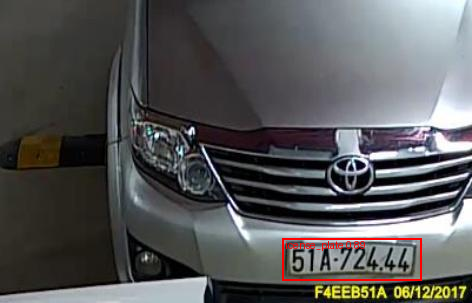

In [19]:
draw = ImageDraw.Draw(image)

colors = {"license_plate": "red"}
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    x, y, x2, y2 = tuple(box)
    label_name = model.config.id2label[label.item()]
    color = colors.get(label_name, "red")
    draw.rectangle((x, y, x2, y2), outline=color, width=2)
    draw.text((x, y), f"{label_name} {score:.2f}", fill=color)

image